<a href="https://colab.research.google.com/github/YeahmanS/yeahmans.github.io/blob/main/DATA_PRE_PROCSSING_UNIT_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import torch

#Accessing data using pandas and some preprocessing

In [ ]:
import os

os.makedirs(os.path.join('..', 'data'), exist_ok=True)
data_file = os.path.join('..', 'data', 'house_tiny.csv')
with open(data_file, 'w') as f:
    f.write('''NumRooms,RoofType,Price
NA,NA,127500
2,NA,106000
4,Slate,178100
NA,NA,140000''')

In [ ]:
import pandas as pd

data = pd.read_csv(data_file)
print(data)

   NumRooms RoofType   Price
0       NaN      NaN  127500
1       2.0      NaN  106000
2       4.0    Slate  178100
3       NaN      NaN  140000


In [ ]:
inputs,target=data.iloc[:,0:2] , data.iloc[:,2]
inputs = pd.get_dummies(inputs, dummy_na=True)
print(inputs)

   NumRooms  RoofType_Slate  RoofType_nan
0       NaN           False          True
1       2.0           False          True
2       4.0            True         False
3       NaN           False          True


In [ ]:
inputs=inputs.fillna(inputs.mean())

In [ ]:
inputs_tensor = torch.tensor(inputs.to_numpy(dtype=float))
target_tensor = torch.tensor(target.to_numpy(dtype=float))
print(inputs_tensor)
print(target_tensor)

tensor([[3., 0., 1.],
        [2., 0., 1.],
        [4., 1., 0.],
        [3., 0., 1.]], dtype=torch.float64)
tensor([127500., 106000., 178100., 140000.], dtype=torch.float64)


**2.2.5. Exercises**

- Try loading datasets, e.g., Abalone from the UCI Machine Learning Repository and inspect their properties. What fraction of them has missing values? What fraction of the variables is numerical, categorical, or text?

- Try indexing and selecting data columns by name rather than by column number. The pandas documentation on indexing has further details on how to do this.

- How large a dataset do you think you could load this way? What might be the limitations? Hint: consider the time to read the data, representation, processing, and memory footprint. Try this out on your laptop. What happens if you try it out on a server?

- How would you deal with data that has a very large number of categories? What if the category labels are all unique? Should you include the latter?

- What alternatives to pandas can you think of? How about loading NumPy tensors from a file? Check out Pillow, the Python Imaging Library.



**Answer:**

3. Loading data into ram will be limitation
4. We will simply drop it as it do not contain much information as all column categories are unique for large number of categories we might try to group by into one we might use vector embeddings
5. Exploring pillow in Next chapter

In [13]:
creditcard=pd.read_excel("/content/default of credit card clients.xls",header=1)

In [15]:
creditcard.head(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [19]:
creditcard.isna().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


In [20]:
creditcard.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

Exercise

In [22]:
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# fetch dataset
abalone = fetch_ucirepo(id=1)

# data (as pandas dataframes)
X = abalone.data.features
y = abalone.data.targets

# metadata
print(abalone.metadata)

# variable information
print(abalone.variables)


{'uci_id': 1, 'name': 'Abalone', 'repository_url': 'https://archive.ics.uci.edu/dataset/1/abalone', 'data_url': 'https://archive.ics.uci.edu/static/public/1/data.csv', 'abstract': 'Predict the age of abalone from physical measurements', 'area': 'Biology', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Tabular'], 'num_instances': 4177, 'num_features': 8, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': [], 'target_col': ['Rings'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1994, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C55C7W', 'creators': ['Warwick Nash', 'Tracy Sellers', 'Simon Talbot', 'Andrew Cawthorn', 'Wes Ford'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting the age of abalone from physical measurements.  The age of abalone is determined by cutting the shell through the cone, staining it, and counting the number of rings through a microscope -- 

In [38]:
aba_data=abalone['data']['original']

In [39]:
aba_data.isna().sum()

,0
Sex,0
Length,0
Diameter,0
Height,0
Whole_weight,0
Shucked_weight,0
Viscera_weight,0
Shell_weight,0
Rings,0


In [40]:
aba_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [61]:
num_cat_col=len(aba_data.select_dtypes("object").columns)
print(num_cat_col)

1


In [62]:
num_num_col=len(aba_data.select_dtypes("number").columns)
print(num_num_col)

8


In [69]:
print(f"Percentage of categorical column in dataset : {round(num_cat_col*100/(num_num_col + num_cat_col),2)}")

Percentage of categorical column in dataset : 11.11


Around 11 percent of column i.e 1 out of 9 is categorical rest are numerical

# TO BE HONEST NOTHING MUCH TO EXPLORE IN 1ST EXERCISE EXCEPT PILLOW LIBRARY

## Pillow Library

In [1]:
!pip install Pillow
from PIL import Image

In [2]:
im =  Image.open("/content/714061fe-9d5e-49a9-a0aa-95f936b73fb3.jpg")

In [5]:
print(im.format, im.size, im.mode)

JPEG (735, 732) RGB


In [8]:
im.show()

In [15]:
import numpy as np
import pandas as pd
np.array(im).sum()

245285304

In [11]:
image=np.array(im)

In [12]:
from PIL import ImageFilter

bluredimage=im.filter(ImageFilter.BLUR)


In [14]:
np.array(bluredimage).sum()

245333613

In [25]:
from PIL import ImageFilter

# Example of creating a custom kernel filter
custom_kernel = [
    0, +1, 0,
    +1, -5,1,
    0, 1, 0
]

image_with_custom_filter = im.filter(ImageFilter.Kernel((3, 3), custom_kernel))


array([[[251, 204, 136],
        [250, 203, 135],
        [248, 201, 133],
        ...,
        [248, 200, 124],
        [247, 199, 123],
        [247, 199, 123]],

       [[253, 206, 138],
        [254, 207, 139],
        [249, 202, 134],
        ...,
        [252, 204, 128],
        [251, 203, 127],
        [247, 199, 123]],

       [[255, 208, 140],
        [252, 205, 137],
        [255, 208, 140],
        ...,
        [251, 203, 125],
        [246, 198, 122],
        [245, 197, 121]],

       ...,

       [[195, 153,  79],
        [193, 150,  74],
        [189, 153,  79],
        ...,
        [185, 153,  92],
        [192, 168,  91],
        [195, 161, 100]],

       [[193, 151,  79],
        [197, 150,  84],
        [186, 146,  82],
        ...,
        [186, 151,  83],
        [191, 156,  96],
        [195, 160,  94]],

       [[192, 150,  78],
        [192, 149,  80],
        [191, 150,  84],
        ...,
        [191, 156,  92],
        [192, 157,  91],
        [195, 160,  92]]], dtype=uint8)
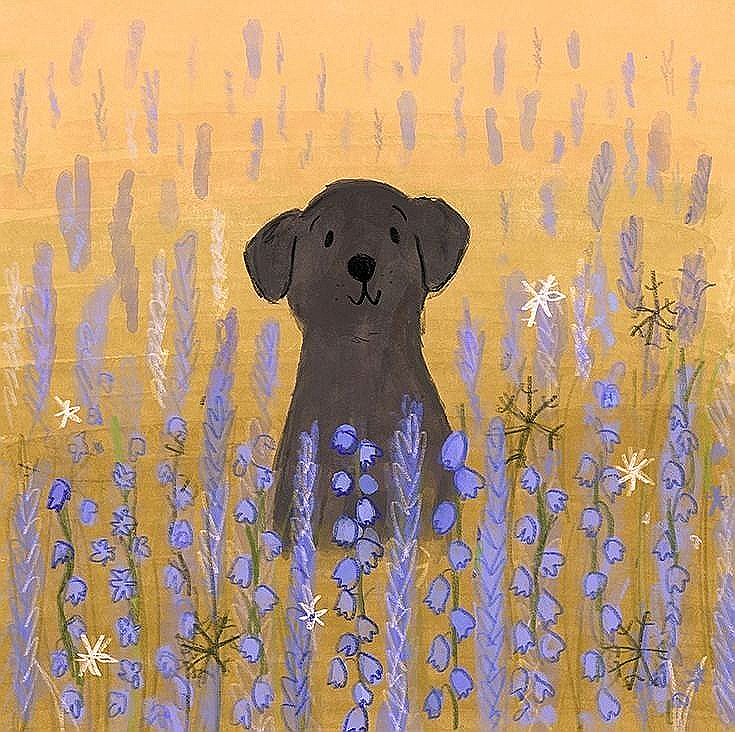

In [26]:
np.array(image_with_custom_filter)

array([[[251, 204, 136],
        [250, 203, 135],
        [248, 201, 133],
        ...,
        [248, 200, 124],
        [247, 199, 123],
        [247, 199, 123]],

       [[253, 206, 138],
        [252, 205, 137],
        [250, 203, 135],
        ...,
        [249, 201, 125],
        [248, 200, 124],
        [247, 199, 123]],

       [[255, 208, 140],
        [253, 206, 138],
        [252, 205, 137],
        ...,
        [248, 200, 124],
        [246, 198, 122],
        [245, 197, 121]],

       ...,

       [[195, 153,  79],
        [193, 151,  79],
        [190, 150,  81],
        ...,
        [189, 157,  96],
        [192, 161,  97],
        [195, 161, 100]],

       [[193, 151,  79],
        [193, 150,  81],
        [190, 149,  83],
        ...,
        [190, 156,  92],
        [192, 158,  94],
        [195, 160,  94]],

       [[192, 150,  78],
        [192, 149,  80],
        [191, 150,  84],
        ...,
        [191, 156,  92],
        [192, 157,  91],
        [195, 160,  92]]], dtype=uint8)
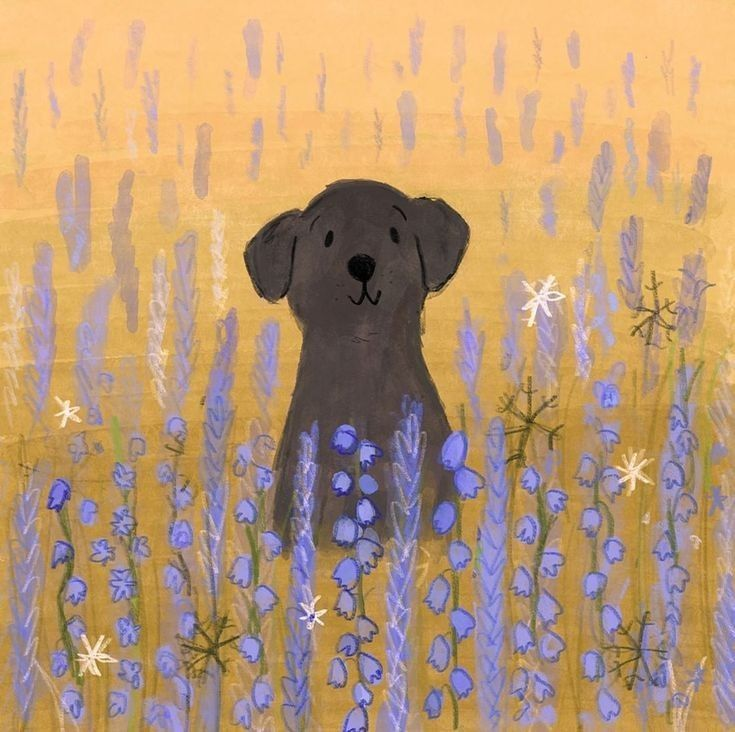

In [20]:
np.array(im)

array([[[255, 226, 124],
        [255, 225, 123],
        [255, 222, 120],
        ...,
        [255, 220, 106],
        [255, 219, 105],
        [255, 219, 105]],

       [[255, 229, 127],
        [255, 228, 126],
        [255, 225, 123],
        ...,
        [255, 222, 108],
        [255, 220, 106],
        [255, 219, 105]],

       [[255, 232, 130],
        [255, 229, 127],
        [255, 228, 126],
        ...,
        [255, 220, 106],
        [255, 217, 103],
        [255, 216, 102]],

       ...,

       [[213, 150,  39],
        [210, 147,  39],
        [205, 145,  42],
        ...,
        [204, 156,  64],
        [208, 162,  66],
        [213, 162,  70]],

       [[210, 147,  39],
        [210, 145,  42],
        [205, 144,  45],
        ...,
        [205, 154,  58],
        [208, 157,  61],
        [213, 160,  61]],

       [[208, 145,  37],
        [208, 144,  40],
        [207, 145,  46],
        ...,
        [207, 154,  58],
        [208, 156,  57],
        [213, 160,  58]]], dtype=uint8)
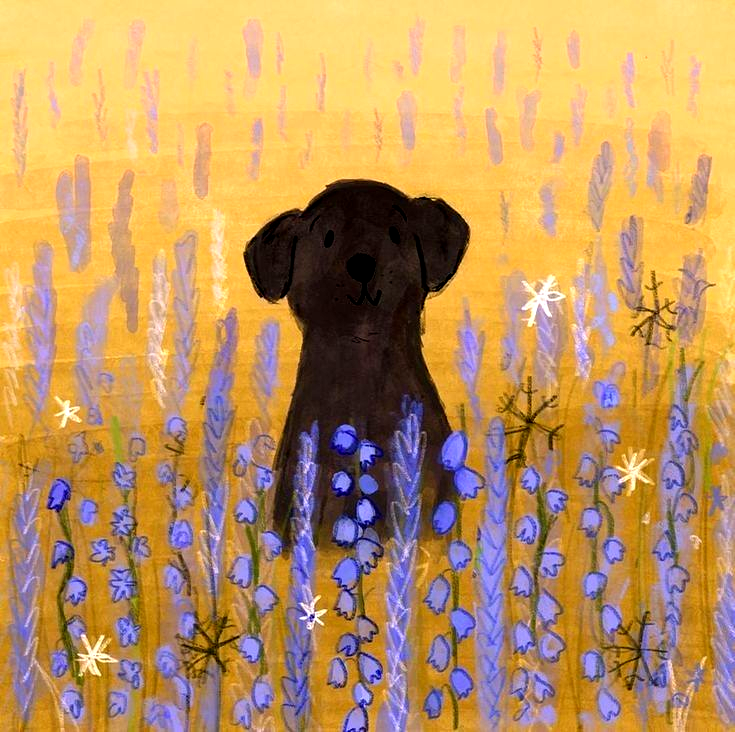

In [27]:
from PIL import Image, ImageEnhance


# Create an ImageEnhance object for contrast
enhancer = ImageEnhance.Contrast(im)

# Adjust the contrast. The factor is a float where:
# 1.0 means original image (no change),
# values greater than 1.0 increase the contrast,
# values between 0.0 and 1.0 decrease the contrast.
contrast_image = enhancer.enhance(1.5)
np.array(contrast_image)

# SOME MORE ARITHMETIC ON TENSORS

In [38]:
A = torch.arange(12,dtype=float).reshape(3,4)
A

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]], dtype=torch.float64)

In [39]:
B = A + A

In [40]:
A+B

tensor([[ 0.,  3.,  6.,  9.],
        [12., 15., 18., 21.],
        [24., 27., 30., 33.]], dtype=torch.float64)

In [41]:
A.sum(axis=0)

tensor([12., 15., 18., 21.], dtype=torch.float64)

In [42]:
A.sum(axis=1)

tensor([ 6., 22., 38.], dtype=torch.float64)

In [45]:
A.mean(),A.mean(axis=0),A.mean(axis=1)

(tensor(5.5000, dtype=torch.float64),
 tensor([4., 5., 6., 7.], dtype=torch.float64),
 tensor([1.5000, 5.5000, 9.5000], dtype=torch.float64))

In [48]:
A.cumsum(axis=1)

tensor([[ 0.,  1.,  3.,  6.],
        [ 4.,  9., 15., 22.],
        [ 8., 17., 27., 38.]], dtype=torch.float64)

In [49]:
A*B

tensor([[  0.,   2.,   8.,  18.],
        [ 32.,  50.,  72.,  98.],
        [128., 162., 200., 242.]], dtype=torch.float64)

In [51]:
#HAMADARD PRODUCT BASICALLY ELEMETN BY ELEMENT
A*A

tensor([[  0.,   1.,   4.,   9.],
        [ 16.,  25.,  36.,  49.],
        [ 64.,  81., 100., 121.]], dtype=torch.float64)

In [53]:
len(torch.arange(24).reshape(2,3,4))

2

In [59]:
C=torch.arange(24).reshape(2,3,4)
C

tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])

In [60]:
C.sum(),C.sum(axis=0),C.sum(axis=1),C.sum(axis=2)

(tensor(276),
 tensor([[12, 14, 16, 18],
         [20, 22, 24, 26],
         [28, 30, 32, 34]]),
 tensor([[12, 15, 18, 21],
         [48, 51, 54, 57]]),
 tensor([[ 6, 22, 38],
         [54, 70, 86]]))

In [65]:
torch.norm(torch.ones((4,9)))

tensor(6.)

In [66]:
torch.ones((4,9))

tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.]])

In [76]:
torch.norm(torch.ones(24 , dtype=float).reshape(3,-1))

tensor(4.8990, dtype=torch.float64)

In [75]:
torch.ones(24 , dtype=float).reshape(3,-1)

tensor([[1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.]], dtype=torch.float64)

In [78]:
torch.ones(2,9)

tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.]])

In [79]:
torch.norm(torch.ones(2,9))

tensor(4.2426)

In [81]:
A=torch.rand(10,16)
B=torch.rand(16,5)
C=torch.rand(5,16)

In [86]:
torch.mm(torch.mm(A,B),C).shape

torch.Size([10, 16])

In [85]:
%timeit torch.mm(torch.mm(A,B),C)

6.58 µs ± 102 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [84]:
%timeit torch.mm(A,torch.mm(B,C))

7.68 µs ± 1.56 µs per loop (mean ± std. dev. of 7 runs, 100000 loops each)
